In [1]:
import os
import numpy as np
import cv2
import tensorflow as tf
from PIL import Image, ImageOps
from sklearn.utils import shuffle
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import load_img, img_to_array


In [2]:
class SequenceDataGenerator(Sequence):
    def __init__(self, directory, batch_size, img_size, sequence_length, shuffle=True):
        self.directory = directory
        self.batch_size = batch_size
        self.img_size = img_size
        self.sequence_length = sequence_length
        self.shuffle = shuffle
        self.class_names = sorted(os.listdir(directory),reverse=True)
        self.samples = self._load_samples()
        self.on_epoch_end()
        
    def _load_samples(self):
        samples = []
        for class_name in self.class_names:
            class_dir = os.path.join(self.directory, class_name)
            for sequence_name in os.listdir(class_dir):
                sequence_dir = os.path.join(class_dir, sequence_name)
                frames = sorted(os.listdir(sequence_dir),key=lambda x: int(x.split('.')[0]))
                samples.append((sequence_dir, frames, self.class_names.index(class_name)))

        return samples
    
    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))
    
    def __getitem__(self, index):
        batch_samples = self.samples[index * self.batch_size:(index + 1) * self.batch_size]
        X, y = self._generate_data(batch_samples)
        return X, y
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.samples)
    
    def _generate_data(self, batch_samples):
        X = np.zeros((self.batch_size, self.sequence_length, *self.img_size, 3), dtype=np.float32)
        y = np.zeros((self.batch_size,), dtype=int)  
        
        for i, (sequence_dir, frames, label) in enumerate(batch_samples):
            for j, frame_name in enumerate(frames[:self.sequence_length]):
                img_path = os.path.join(sequence_dir, frame_name)
                img = load_img(img_path, target_size=self.img_size)
                img_array = img_to_array(img) / 255.0
                X[i, j, :, :, :] = img_array
            y[i] = label
        
        return X, y


In [3]:
train_dir = 'up-close-reshaped-64/train'
val_dir = 'up-close-reshaped-64/dev'
test_dir = 'up-close-reshaped-64/test'

batch_size = 32
img_size = (64, 64)
sequence_length = 30

train_gen = SequenceDataGenerator(train_dir, batch_size, img_size, sequence_length)
val_gen = SequenceDataGenerator(val_dir, batch_size, img_size, sequence_length)
test_gen = SequenceDataGenerator(test_dir, batch_size, img_size, sequence_length, shuffle=False)


In [4]:
import matplotlib.pyplot as plt
def show_first_sequences(generator, num_sequences=5):
    class_names = generator.class_names
    sequences_shown = 0
    
    for X, y in generator:
        for j in range(min(generator.batch_size, num_sequences - sequences_shown)):
            plt.figure(figsize=(15, 3))
            for k in range(generator.sequence_length):
                plt.subplot(1, generator.sequence_length, k + 1)
                plt.imshow(X[j, k])
                plt.axis('off')
            plt.suptitle(f'Sequence {sequences_shown + 1}, Label: {class_names[y[j]]} , {y[j]}')
            plt.show()
            sequences_shown += 1
            if sequences_shown >= num_sequences:
                return

Primeras 5 secuencias del conjunto de entrenamiento:


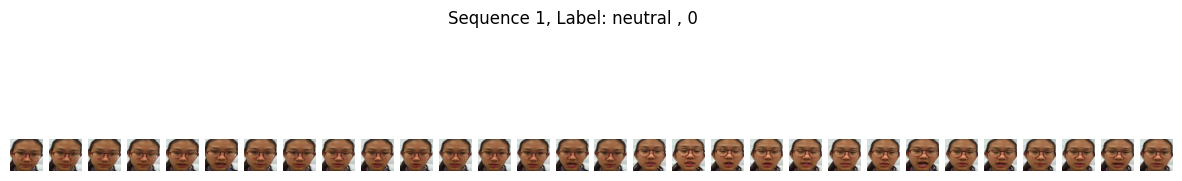

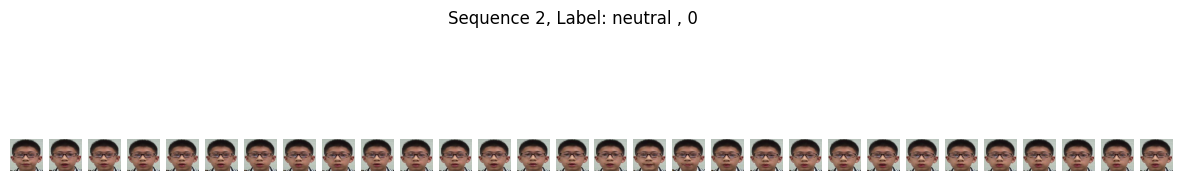

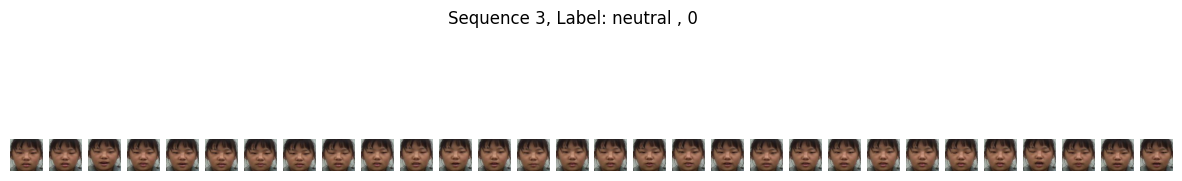

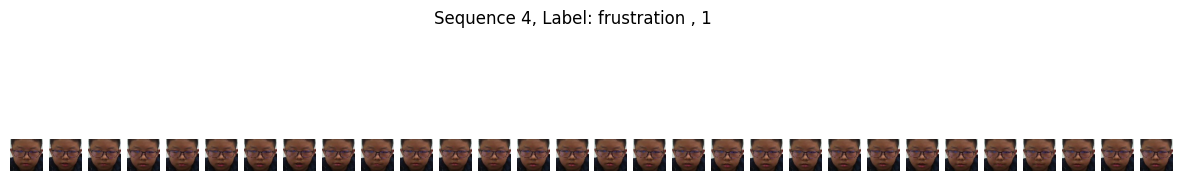

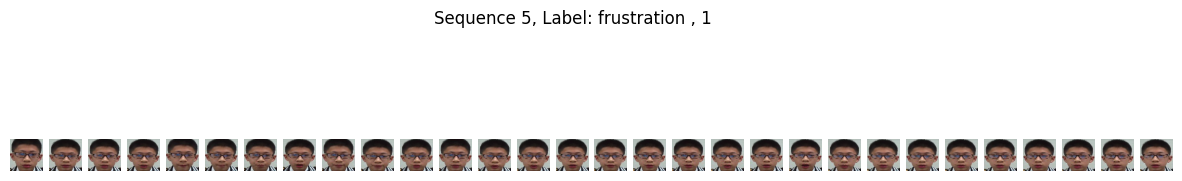

In [5]:
print("Primeras 5 secuencias del conjunto de entrenamiento:")
show_first_sequences(train_gen)

In [6]:
input_shape = (30, 64, 64, 3)  # (frames, height, width, channels)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, BatchNormalization, MaxPooling2D
from tensorflow.keras.layers import Flatten, LSTM, Dense, Dropout, Bidirectional


model = Sequential()


model.add(TimeDistributed(Conv2D(32, (3, 3), activation='relu'), input_shape=(sequence_length, 64, 64, 3)))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))

model.add(TimeDistributed(Conv2D(64, (3, 3), activation='relu')))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))

model.add(TimeDistributed(Conv2D(128, (3, 3), activation='relu')))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))
model.add(TimeDistributed(Dropout(0.2))) 

model.add(TimeDistributed(Flatten()))


model.add(LSTM(256, return_sequences=False))

model.add(Dense(2, activation="softmax"))

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDistr  (None, 30, 62, 62, 32)   896       
 ibuted)                                                         
                                                                 
 time_distributed_1 (TimeDis  (None, 30, 62, 62, 32)   128       
 tributed)                                                       
                                                                 
 time_distributed_2 (TimeDis  (None, 30, 31, 31, 32)   0         
 tributed)                                                       
                                                                 
 time_distributed_3 (TimeDis  (None, 30, 29, 29, 64)   18496     
 tributed)                                                       
                                                                 
 time_distributed_4 (TimeDis  (None, 30, 14, 14, 64)   0

In [9]:
model.compile(loss="sparse_categorical_crossentropy",optimizer='adam',metrics=['accuracy'])

In [10]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

In [11]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

In [12]:
history = model.fit(train_gen, epochs=10, batch_size=32, validation_data=val_gen,callbacks=[early_stopping, reduce_lr])

Epoch 1/10


c:\Users\jpret\anaconda3\envs\tesis\lib\site-packages\tensorflow\python\data\ops\structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


223/223 [==============================] - 102s 438ms/step - loss: 0.5477 - accuracy: 0.7297 - val_loss: 0.3680 - val_accuracy: 0.8973 - lr: 0.0010
Epoch 2/10
223/223 [==============================] - 60s 269ms/step - loss: 0.3748 - accuracy: 0.8390 - val_loss: 0.3061 - val_accuracy: 0.8929 - lr: 0.0010
Epoch 3/10
223/223 [==============================] - 60s 267ms/step - loss: 0.2456 - accuracy: 0.9082 - val_loss: 0.7281 - val_accuracy: 0.6786 - lr: 0.0010
Epoch 4/10
223/223 [==============================] - 62s 276ms/step - loss: 0.1650 - accuracy: 0.9399 - val_loss: 0.3377 - val_accuracy: 0.8579 - lr: 0.0010
Epoch 5/10
223/223 [==============================] - 59s 263ms/step - loss: 0.1112 - accuracy: 0.9612 - val_loss: 0.2343 - val_accuracy: 0.9137 - lr: 0.0010
Epoch 6/10
223/223 [==============================] - 59s 263ms/step - loss: 0.0861 - accuracy: 0.9724 - val_loss: 0.2557 - val_accuracy: 0.9159 - lr: 0.0010
Epoch 7/10
223/223 [==============================] - 59s 263m

In [13]:
model.save('cnnT2D-3-Layers-lstm-256.h5')

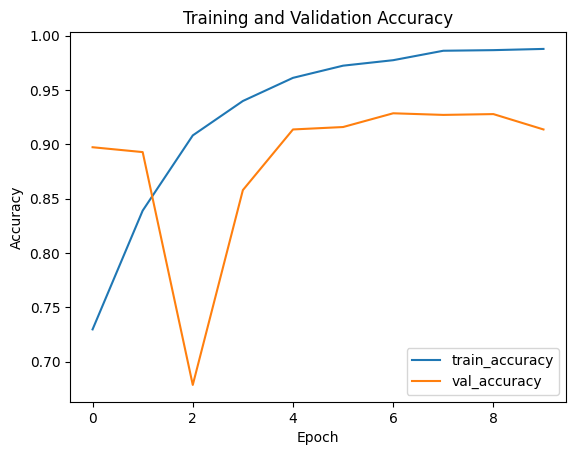

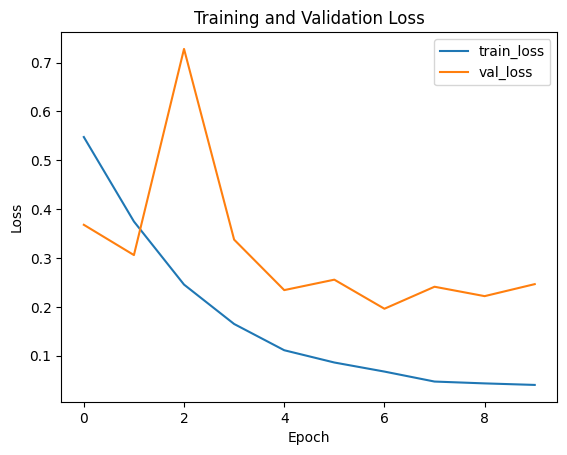

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [15]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

true_labels = []
num_batches = len(test_gen)
i = 0
for _ in range(num_batches):
    _, batch_y = test_gen[i]
    true_labels.extend(batch_y)
    i += 1

In [16]:
# Genera todas las predicciones de una vez
all_predictions = model.predict(test_gen)
pred_labels = np.argmax(all_predictions, axis=1)


42/42 [==============================] - 9s 211ms/step


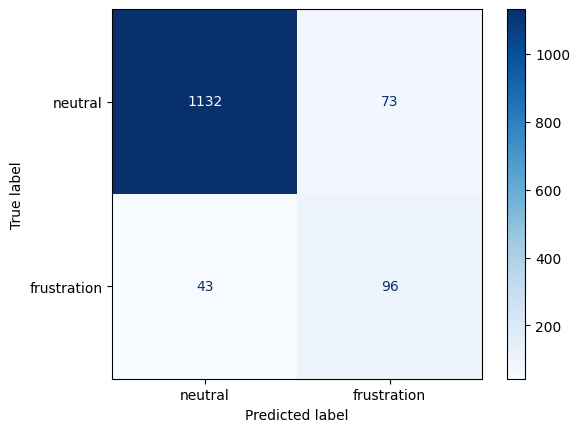

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Calcula la matriz de confusión
conf_matrix = confusion_matrix(true_labels, pred_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=test_gen.class_names)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [18]:
from sklearn.metrics import classification_report
report = classification_report(true_labels, pred_labels)
print(report)

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1205
           1       0.57      0.69      0.62       139

    accuracy                           0.91      1344
   macro avg       0.77      0.82      0.79      1344
weighted avg       0.92      0.91      0.92      1344

